In [112]:
%reload_ext autoreload
%autoreload 2

import os, glob, sys
import pandeia.engine
import stsynphot
import synphot
from synphot import SpectralElement
from synphot.models import Empirical1D
import numpy as np
from astropy.io import fits
import astropy.units as u
import astropy.constants as const
from scipy import interpolate
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import matplotlib as mpl
from rsg import rsg_phot
from tqdm import tqdm
import copy
import pandas as pd
%matplotlib inline

In [2]:
syn_rsg = rsg_phot()
rsgspec = syn_rsg.create_rsg(0.5, 4.4 * u.Lsun, 3500 * u.K, 1000 * u.K, 16.07 * u.Mpc)
filts = ['f070w', 'f090w', 'f115w', 'f150w', 'f182m', 'f200w', 'f210m', 'f277w', 'f335m', 'f356w', 'f444w']
rsgmag = syn_rsg.compute_rsg_mag(filts, 0.5, 4.4 * u.Lsun, 3500 * u.K, 1000 * u.K, 16.07 * u.Mpc)

In [3]:
wvs = rsgspec.waveset
rsgspec(wvs)

<Quantity [2.42837812e-10, 4.08509627e-10, 2.54871705e-10, ...,
           1.54747196e-09, 1.60105752e-09, 1.51308831e-09] PHOTLAM>

Text(0, 0.5, 'photlam $(\\text{photons}/\\text{s}/\\text{cm}^2/\\AA)$')

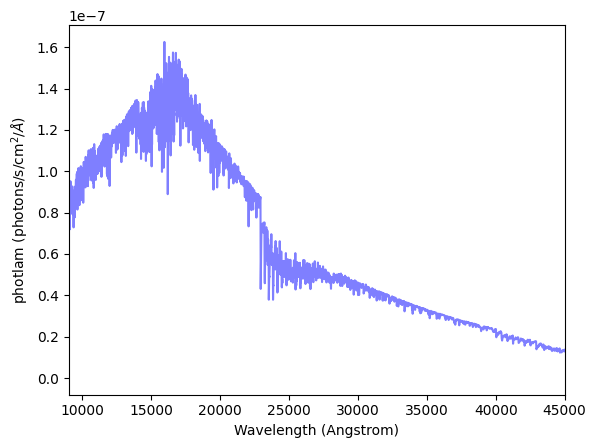

In [4]:
wvs = rsgspec.waveset
plt.plot(wvs, rsgspec(wvs), color = 'blue', alpha = 0.5)
plt.xlim(9000, 45000)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel(r'photlam $(\text{photons}/\text{s}/\text{cm}^2/\AA)$')

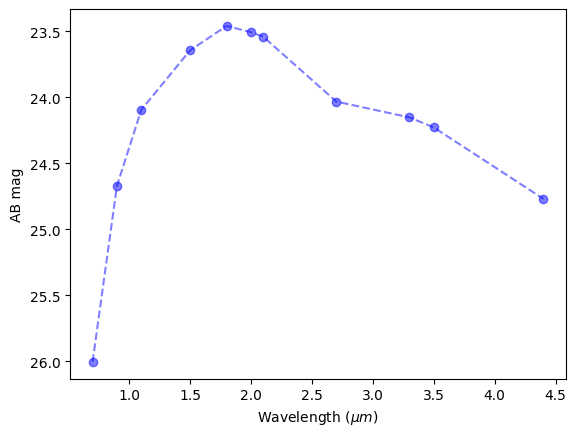

In [5]:
wvs = [float(i[1:3])/10 for i in filts]
mags = [rsgmag[flt].value for flt in filts]
plt.plot(wvs, mags, color = 'blue', alpha = 0.5, marker = 'o', linestyle = '--')
plt.xlabel(r'Wavelength (${\mu}m$)')
plt.ylabel('AB mag')
plt.gca().invert_yaxis()

In [24]:
params = ['lum', 'tau', 'temp']
filts = ['f090w', 'f115w', 'f150w', 'f164n', 'f187n', 'f200w', 'f212n', 'f277w', 'f300m', 'f335m', 'f356w', 'f360m', 'f405n', 'f444w']
modeldf = pd.DataFrame(columns=params+filts)
syn_rsg = rsg_phot()
rsg_temps = np.linspace(3000, 5000, 11) * u.K
taus = np.linspace(0.01, 5, 11)
lums = np.linspace(4, 5, 11) * u.Lsun

f090w_mag, f150w_mag, f277w_mag = [], [], []

for lum in tqdm(lums):
    for tau in taus:
        for temp in rsg_temps:
            try:
                rsgmag = syn_rsg.compute_rsg_mag(filts, tau, lum, temp, 1000 * u.K, 12.474*u.Mpc)
                modeldf.loc[len(modeldf)] = [lum.value, tau, temp.value] + [i.value for i in rsgmag.values()]
            except:
                 modeldf.loc[len(modeldf)] = [lum.value, tau, temp.value] + [np.nan]*len(filts)

100%|██████████| 11/11 [08:25<00:00, 45.95s/it]


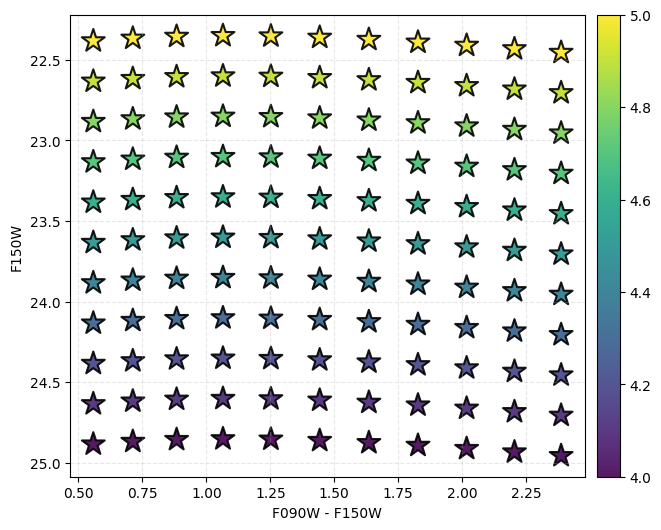

In [18]:
flt_1, flt_2 = 'f090w', 'f150w'
plt.figure(figsize = (8, 6))
plt.scatter(f090w_mag-f150w_mag, f150w_mag, marker='*', s=300, c=np.repeat(lums.value, 11),
            cmap='viridis', edgecolors='black', lw=1.5, alpha=0.9)
plt.colorbar(pad = 0.02)
plt.xlabel(f'{flt_1.upper()} - {flt_2.upper()}')
plt.ylabel(f'{flt_2.upper()}')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3, linestyle='--')

In [79]:
cat = None
for fl in glob.glob('data/dolphot/ngc5643/proc/ngc5643_0_*.csv'):
    if cat is None:
        cat = pd.read_csv(fl)
    else:
        df_ = pd.read_csv(fl)
        cat = pd.concat([cat, df_])
cat.reset_index(inplace=True)

In [7]:
def lin(x, m, c):
    return m*x+c

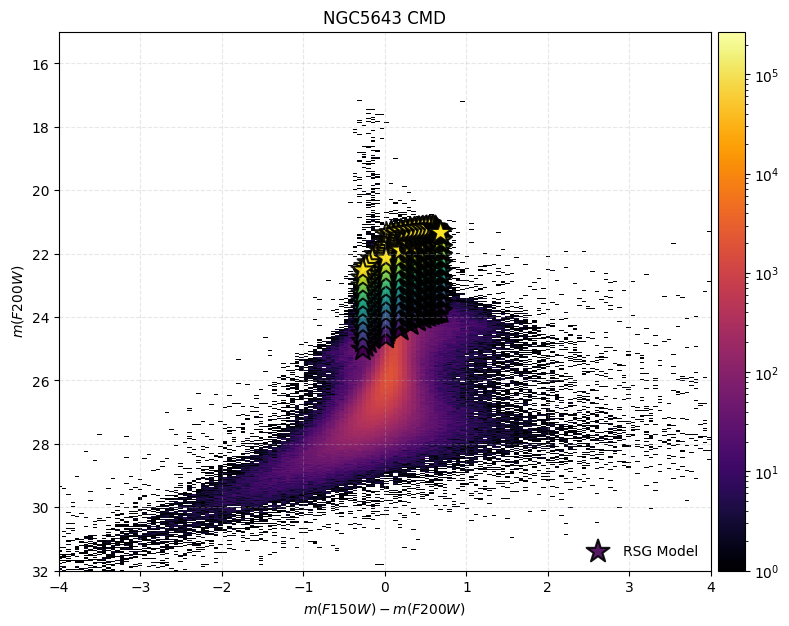

In [132]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2 = 'F150W', 'F200W'

cl, m = cat[f1+'_mag'] - cat[f2+'_mag'], cat[f2+'_mag']

hist = ax.hist2d(cl, m, bins = 3000, norm = 'log', cmap = 'inferno')
ax.scatter(modeldf[f1.lower()] - modeldf[f2.lower()], modeldf[f2.lower()], marker='*', s=300, c=np.repeat(rsg_temps.value, 121),
            cmap='viridis', edgecolors='black', lw=1.5, alpha=0.9, label = 'RSG Model')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-4, 4)
ax.set_ylim(32, 15)
plt.show()

In [133]:
jwst_wv = np.array([0.9, 1.15, 1.5, 1.64, 1.87, 2, 2.12, 2.77, 3, 3.35, 3.56, 3.6, 4.05, 4.44])

(35.0, 15.0)

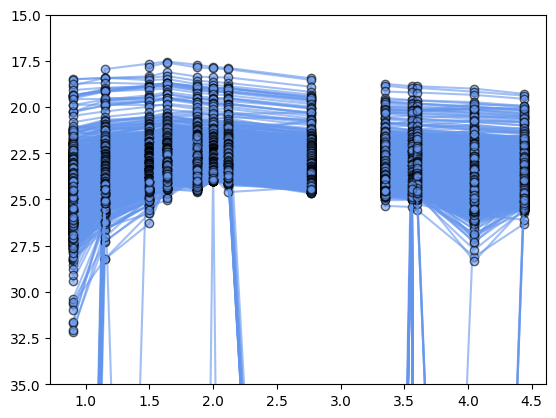

In [18]:
fig, ax = plt.subplots(1, 1)
for idx in cat[m<24].index[:3000]:
    st = cat[m<24].loc[idx][['F090W_mag', 'F115W_mag', 'F150W_mag', 'F164N_mag', 'F187N_mag', 'F200W_mag', 'F212N_mag', 'F277W_mag', 'F300M_mag', 'F335M_mag', 'F356W_mag', 'F360M_mag', 'F405N_mag', 'F444W_mag']].to_numpy().flatten()
    ax.plot(jwst_wv, st, marker = 'o', color = 'cornflowerblue', markeredgecolor = 'black', alpha = 0.6)
ax.set_ylim(35, 15)

Text(0, 0.5, 'AB Mag')

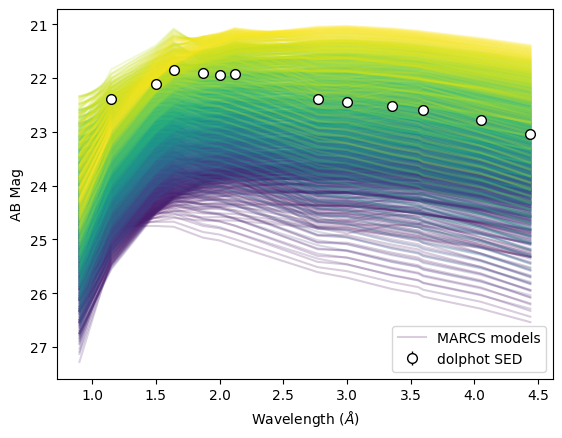

In [ ]:
idx = cat[(m<25) & (cl > -0.5) & (cl < 1)].sample(1).index[0]
st = cat.loc[idx].to_numpy()
mag, magerr = st[7:21], st[21:]
nanmask = (mag>99) | (magerr>9)
mag[nanmask], magerr[nanmask] = np.nan, np.nan
fig, ax = plt.subplots(1, 1)
ax.errorbar(x=jwst_wv, y=mag, yerr=magerr, marker='o', markerfacecolor='white', markeredgecolor='black', 
            markersize=7, lw=0, ecolor='black', elinewidth=1, label = 'dolphot SED')

n_lines = 1331
c = np.arange(1, n_lines + 1)
norm = mpl.colors.Normalize(vmin=c.min(), vmax=c.max())
cmap = mpl.cm.ScalarMappable(norm=norm, cmap=mpl.cm.viridis)
cmap.set_array([])

for i, idx in enumerate(modeldf.index):
    model_st = modeldf.iloc[idx][filts].to_numpy().flatten()
    if i==0:
        ax.plot(jwst_wv, model_st, c=cmap.to_rgba(i+1), markeredgecolor = 'black', alpha = 0.2, label = 'MARCS models')
    else:
        ax.plot(jwst_wv, model_st, c=cmap.to_rgba(i+1), markeredgecolor = 'black', alpha = 0.2)

plt.gca().invert_yaxis()
plt.legend()
plt.xlabel(r'Wavelength $(\AA)$')
plt.ylabel('AB Mag')
# plt.savefig('plots/sed.png', bbox_inches = 'tight')

(35.0, 15.0)

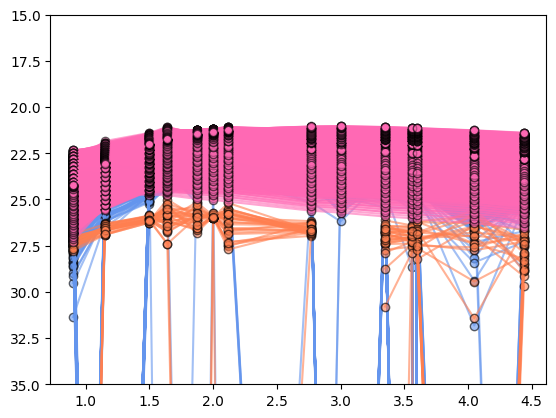

In [104]:
fig, ax = plt.subplots(1, 1)
for idx in cat[m<24].index[8000:11030]:
    st = cat.loc[idx][['F090W_mag', 'F115W_mag', 'F150W_mag', 'F164N_mag', 'F187N_mag', 'F200W_mag', 'F212N_mag', 'F277W_mag', 'F300M_mag', 'F335M_mag', 'F356W_mag', 'F360M_mag', 'F405N_mag', 'F444W_mag']].to_numpy().flatten()
    ax.plot(jwst_wv, st, marker = 'o', color = 'cornflowerblue', markeredgecolor = 'black', alpha = 0.6)
for idx in cat[(m < 26) & (m > 24)].index[:30]:
    st = cat.loc[idx][['F090W_mag', 'F115W_mag', 'F150W_mag', 'F164N_mag', 'F187N_mag', 'F200W_mag', 'F212N_mag', 'F277W_mag', 'F300M_mag', 'F335M_mag', 'F356W_mag', 'F360M_mag', 'F405N_mag', 'F444W_mag']].to_numpy().flatten()
    ax.plot(jwst_wv, st, marker = 'o', color = 'coral', markeredgecolor = 'black', alpha = 0.6)
for idx in modeldf.index:
    st = modeldf.iloc[idx][filts].to_numpy().flatten()
    ax.plot(jwst_wv, st, marker = 'o', color = 'hotpink', markeredgecolor = 'black', alpha = 0.6)
ax.set_ylim(35, 15)

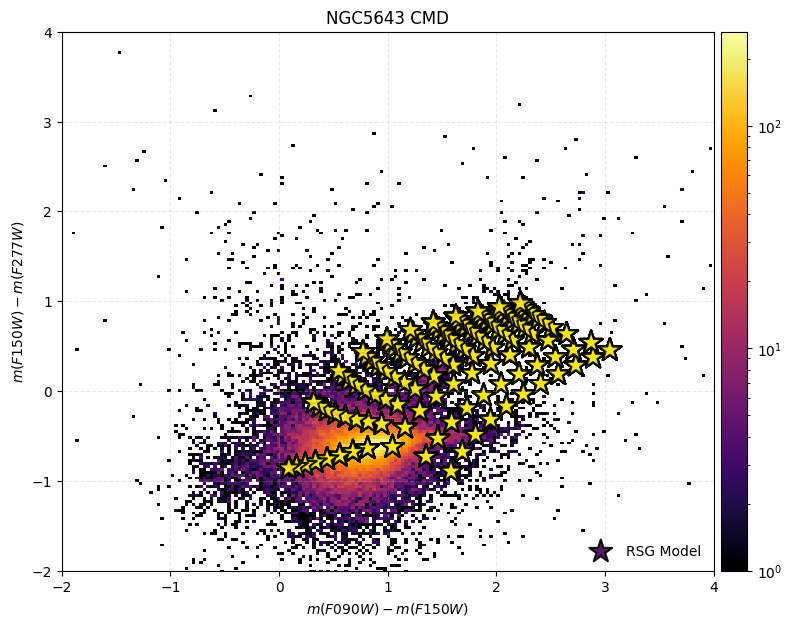

In [178]:
fig, ax = plt.subplots(1, 1, figsize = (10, 7))
f1, f2, f3 = 'F090W', 'F150W', 'F277W'

hist = ax.hist2d(col, mag, bins = 5000, norm = 'log', cmap = 'inferno')
ax.scatter(f090w_mag-f150w_mag, f150w_mag-f277w_mag, marker='*', s=300, c=np.repeat(rsg_temps.value, 121),
            cmap='viridis', edgecolors='black', lw=1.5, alpha=0.9, label = 'RSG Model')

# ax.plot(np.linspace(-2, 4, 100), lin(np.linspace(-2, 4, 100), -13.33, 23), color = 'black', linestyle = '--', label = 'Massey+21')
# ax.plot(np.linspace(-2, 1.25, 100), lin(np.linspace(-2, 1.25, 100), -8, 30), color = 'cornflowerblue', linestyle = '--', label = 'Ren+21')
# ax.plot(np.linspace(1.25, 4, 100), lin(np.linspace(1.25, 4, 100), 0, 20), color = 'silver', linestyle = '--')

cbar = fig.colorbar(hist[3], ax = ax, pad = 0.009)
ax.set_xlabel(rf'$m({f1}) - m({f2})$')
ax.set_ylabel(rf'$m({f2}) - m({f3})$')
ax.set_title('NGC5643 CMD')

ax.legend(loc = 'lower right', framealpha = 0)
ax.tick_params(axis='both', which='major')
ax.tick_params(axis='both', which='minor')
cbar.ax.tick_params() 
ax.grid(alpha = 0.3, linestyle = '--')
ax.set_xlim(-2, 4)
ax.set_ylim(-2, 4)
plt.show()

In [35]:
from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [36]:
pca = PCA(n_components=2)
ica = FastICA(n_components=2)
std_scaler = StandardScaler()
mmax_scaler = MinMaxScaler()

In [45]:
nanmask = []
for col in ['F090W_mag', 'F115W_mag', 'F150W_mag', 'F200W_mag', 'F277W_mag', 'F356W_mag']:
    if len(nanmask) == 0:
        nanmask = np.isnan(cat[col])
    else:
        nanmask = nanmask & np.isnan(cat[col])

In [113]:
model_mags = np.vstack([f090w_mag, f150w_mag, f277w_mag])
stacked_mags = np.hstack([mags, model_mags])
# stacked_mags = copy.copy(mags)
smg = []

mask = (stacked_mags[0] < 26) & (stacked_mags[1] <26) & (stacked_mags[2] < 26)
smg.append(stacked_mags[0][mask])
smg.append(stacked_mags[1][mask])
smg.append(stacked_mags[2][mask])
smg = np.array(smg)
stacked_mags = smg
icm = np.array(len(mags[0])*[True] + len(model_mags[0])*[False])[mask]

scaled_mags = mmax_scaler.fit_transform(stacked_mags)
fit_input = stacked_mags
pca.fit(fit_input)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


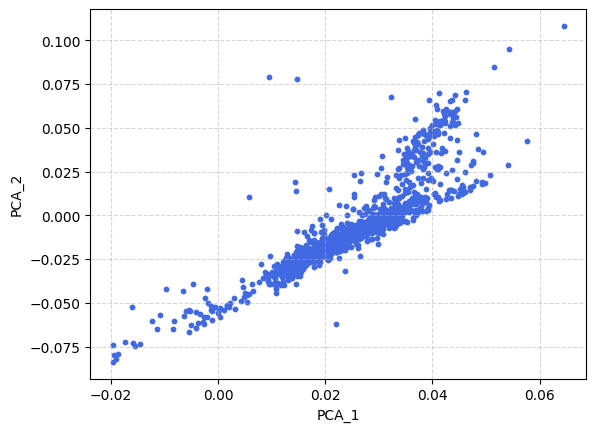

In [108]:
plt.scatter(pca.components_[0], pca.components_[1], s = 10, color = 'royalblue')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
# plt.xlim(-0.002, 0.002)
# plt.ylim(-0.005, 0.005)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

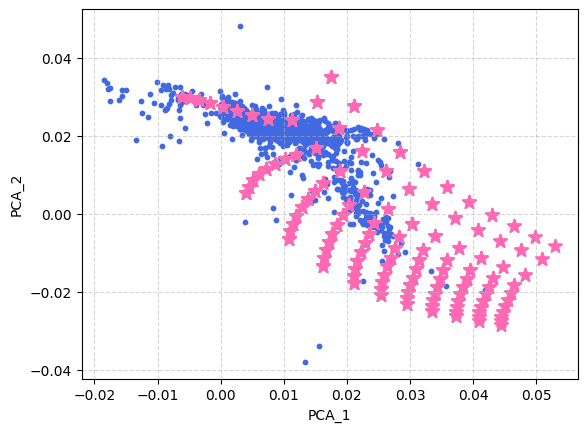

In [110]:
plt.scatter(pca.components_[0][icm], pca.components_[1][icm], s = 10, color = 'royalblue')
plt.scatter(pca.components_[0][~icm], pca.components_[1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
# plt.xlim(-0.002, 0.002)
# plt.ylim(-0.005, 0.005)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

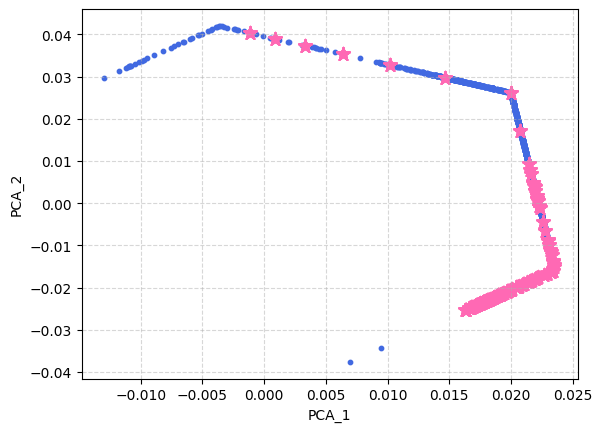

In [112]:
plt.scatter(pca.components_[0][icm], pca.components_[1][icm], s = 10, color = 'royalblue')
plt.scatter(pca.components_[0][~icm], pca.components_[1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('PCA_1')
plt.ylabel('PCA_2')
# plt.xlim(-0.002, 0.002)
# plt.ylim(-0.005, 0.005)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

In [78]:
model_mags = np.vstack([f090w_mag, f150w_mag, f277w_mag])
smg = []
stacked_mags = np.hstack([mags, model_mags])

mask = (stacked_mags[0] < 80) & (stacked_mags[1] < 80) & (stacked_mags[2] < 80)
smg.append(stacked_mags[0][mask])
smg.append(stacked_mags[1][mask])
smg.append(stacked_mags[2][mask])
smg = np.array(smg)
stacked_mags = smg
icm = np.array(len(mags[0])*[True] + len(model_mags[0])*[False])[mask]

scaled_mags = std_scaler.fit_transform(stacked_mags)
fit_input = stacked_mags
ica.fit(fit_input)

,n_components,2
,algorithm,'parallel'
,whiten,'unit-variance'
,fun,'logcosh'
,fun_args,None
,max_iter,200
,tol,0.0001
,w_init,None
,whiten_solver,'svd'
,random_state,None


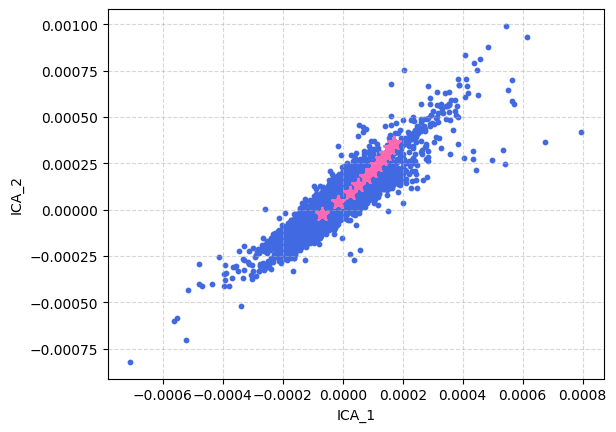

In [79]:
plt.scatter(ica.components_[0][icm], ica.components_[1][icm], s = 10, color = 'royalblue')
plt.scatter(ica.components_[0][~icm], ica.components_[1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('ICA_1')
plt.ylabel('ICA_2')
# plt.xlim(-1e-5, 1e-5)
# plt.ylim(-2e-5, 2e-5)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

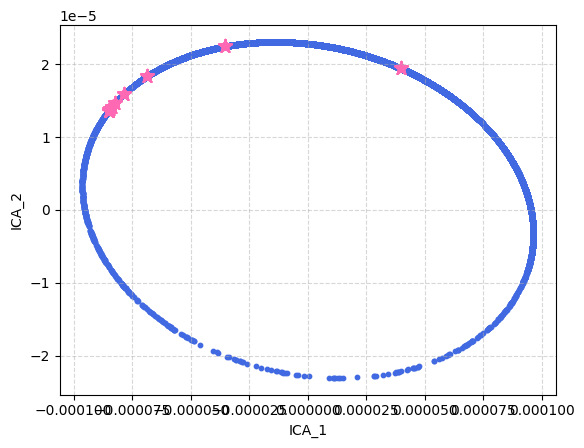

In [76]:
plt.scatter(ica.components_[0][icm], ica.components_[1][icm], s = 10, color = 'royalblue')
plt.scatter(ica.components_[0][~icm], ica.components_[1][~icm], s = 100, marker = '*', color = 'hotpink')
plt.xlabel('ICA_1')
plt.ylabel('ICA_2')
# plt.xlim(-1e-5, 1e-5)
# plt.ylim(-2e-5, 2e-5)
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()